<!--
Software Name : learning-parities-with-product-networks
SPDX-FileCopyrightText: Copyright (c) 2026 Orange S.A.
SPDX-License-Identifier: MIT

This software is distributed under the MIT License .,
see the "LICENSE.md" file for more details or https://opensource.org/licenses/MIT

Author: Guillaume Larue, guillaume.larue@orange.com
Software description: Source code of the paper "Learning High-Dimensional Parity Functions with Product Networks"
-->

# Study D — Optimal Learning Rate $\alpha^*$ vs Problem Size $N$

Identifies the value of $\alpha$ minimising convergence time for each $N$, under unit sparsity ($p_e = 1/N$). Validates theoretical bounds from §4.3 and characterises the scaling law $\alpha^* \propto N$ (and $\alpha^\text{lim} \propto N$).

**Data generated by:** [run_study_D.py](../studies/run_study_D.py)  
**Paper section:** Section 5.2.3 - Impact of The Learning Rate $\alpha$ (Figure 5)

| Parameter | Value |
|-----------|-------|
| Problem Size $N$          | [10, 1000] (20 values, log-spaced) |
| Num. Parallel Nodes $P$   | $\lfloor 1000 / N \rfloor$ |
| Learning Rate $\alpha$    | [N/6, 2N/3]  (50 values, log-spaced) |
| Batch Size $M$            | 50000 |
| Bernouilli Prob. $p_e$    | $1/N$ |
| Max. Steps $S$            | $\approx 30000$ | 
| Oracle Proportion $p_w$   | 0.5 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import sys
import os
import glob

# Add parent directory to path
sys.path.append('..')

from plotting.plot_utility import plot_metric_vs_param, compute_steps_to_thresholds, setup_plot_style

%matplotlib inline
setup_plot_style()

In [2]:
def get_latest_study_folder(study_prefix):
    pattern = f'../studies/results/{study_prefix}_*/'
    folders = glob.glob(pattern)
    if folders:
        return max(folders)  # Latest by name (timestamp-based)
    return None

mode = 'auto'  # Change to 'manual' to specify your own path

if mode == 'auto':
    results_dir = get_latest_study_folder('D_alpha_optimal')
    if results_dir is None:
        raise FileNotFoundError("No Study D results found. Run run_study_D.py first.")
    print(f"Auto-detected folder: {results_dir}")
else:
    results_dir = '../studies/results/D_alpha_optimal_XXXXXXXX_XXXXXX/'
    print(f"Using manual path: {results_dir}")

n_values = np.load(results_dir + 'n_values.npy')
optimal_alpha_per_n = np.load(results_dir + 'optimal_alpha_per_n.npy')
optimal_steps_per_n = np.load(results_dir + 'optimal_steps_per_n.npy')

print(f"\nN range: {n_values[0]} to {n_values[-1]}")
print(f"Number of N values: {len(n_values)}")
print(f"\nOptimal alpha for each N:")
for N, alpha, steps in zip(n_values, optimal_alpha_per_n, optimal_steps_per_n):
    print(f"  N={N:4d}: alpha={alpha:.6f}, steps={steps:4.0f}")

# Identify optimal and first-diverging alpha per N
alpha_value_optimal_per_N = []
alpha_value_first_divergence_per_N = []
plot_convergence = False
for N in n_values:
    alpha_values = np.load(results_dir + f'N_{N}_alpha_values.npy')
    p_diff_matrix = np.load(results_dir + f'N_{N}_p_diff_matrix.npy')

    if plot_convergence:
        plt.figure(figsize=(6, 4))

    optimal_steps = +np.inf
    alpha_id_optimal = None
    alpha_id_first_divergence = -1
    for alpha_id in range(len(alpha_values)):
        color = "blue"
        p_diff_at_alpha = p_diff_matrix[alpha_id, :]

        previous_p_diff = p_diff_at_alpha[0]
        div_threshold = 0.05
        for i in range(len(p_diff_at_alpha)):
            if np.isnan(p_diff_at_alpha[i]) or (p_diff_at_alpha[i] > div_threshold and previous_p_diff < div_threshold):
                color = 'red'
                if alpha_id_first_divergence == -1:
                    alpha_id_first_divergence = alpha_id
                break
            if p_diff_at_alpha[i] < 0.01:
                color = 'green'
                if i < optimal_steps:
                    optimal_steps = i
                    alpha_id_optimal = alpha_id
                break
            previous_p_diff = p_diff_at_alpha[i]

        if plot_convergence:
            plt.plot(p_diff_at_alpha, color=color, label=f'alpha_id={alpha_id}/alpha_value={alpha_values[alpha_id]:.6f}')

    print(f"Optimal alpha_id : {alpha_id_optimal}, alpha_value: {alpha_values[alpha_id_optimal]:.6f}")
    print(f"First alpha_id with divergence: {alpha_id_first_divergence}, alpha_value: {alpha_values[alpha_id_first_divergence]:.6f}\n")
    alpha_value_optimal_per_N.append(alpha_values[alpha_id_optimal])
    alpha_value_first_divergence_per_N.append(alpha_values[alpha_id_first_divergence])

    if plot_convergence:
        plt.yscale('log')
        plt.xlim(0, 100)
        plt.show()

Auto-detected folder: ../studies/results/D_alpha_optimal_20260420_203622/

N range: 10 to 1000
Number of N values: 20

Optimal alpha for each N:
  N=  10: alpha=3.577636, steps=   6
  N=  12: alpha=4.293163, steps=   6
  N=  16: alpha=5.724217, steps=   6
  N=  20: alpha=7.155271, steps=   6
  N=  26: alpha=9.568776, steps=   6
  N=  33: alpha=12.144985, steps=   6
  N=  42: alpha=15.026069, steps=   6
  N=  54: alpha=24.921392, steps=   5
  N=  69: alpha=31.844001, steps=   5
  N=  88: alpha=39.479739, steps=   5
  N= 112: alpha=51.688813, steps=   5
  N= 143: alpha=67.889329, steps=   5
  N= 183: alpha=84.455829, steps=   5
  N= 233: alpha=110.616878, steps=   5
  N= 297: alpha=133.244119, steps=   5
  N= 379: alpha=174.911252, steps=   5
  N= 483: alpha=222.908008, steps=   5
  N= 615: alpha=291.971589, steps=   5
  N= 784: alpha=361.821693, steps=   5
  N=1000: alpha=474.750551, steps=   5
Optimal alpha_id : 27, alpha_value: 3.577636
First alpha_id with divergence: 43, alpha_value:

## Optimal $\alpha$ vs $N$

Empirically optimal learning rate $\alpha^*(N)$ plotted against $N$, alongside the theoretical bounds $\alpha_0$, $\alpha_1$, $\alpha_2$ derived in §4.3. The ratio $\alpha^*/N$ is shown to be approximately constant.

See Paper Section 5.2.3 Figure 5

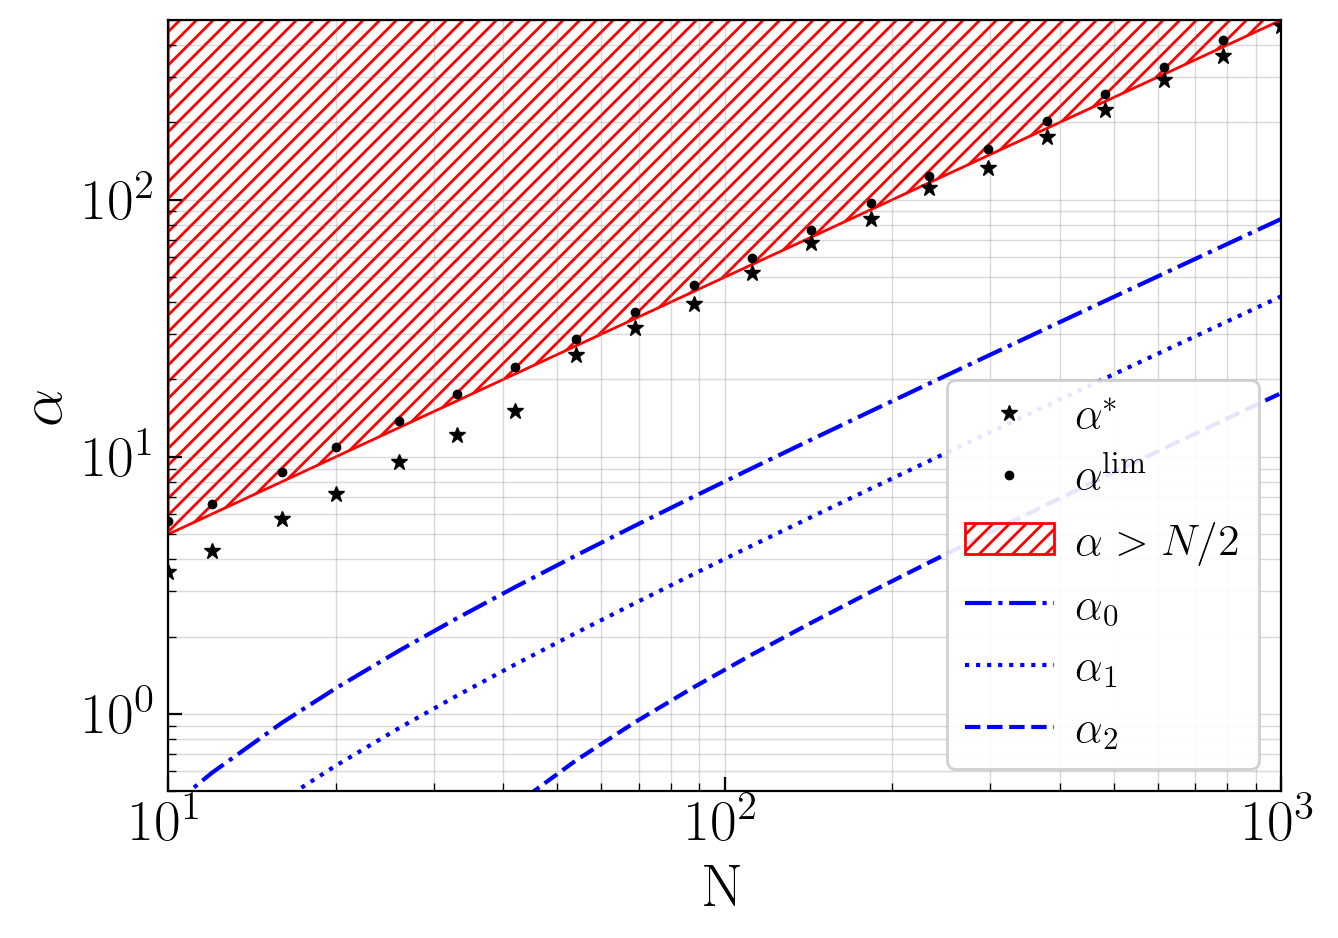

In [3]:
fig, ax = plt.subplots()

ax.plot(n_values, alpha_value_optimal_per_N, marker='*', color='black', linewidth=0, label='$\\alpha^*$')
ax.plot(n_values, alpha_value_first_divergence_per_N, marker='.', color='black', linewidth=0, label='$\\alpha^\\mathrm{lim}$')

a = 1/2
b = 0
ax.fill_between(n_values, a*n_values+b, 1e3, hatch="////", facecolor="none", edgecolor="red", label='$\\alpha > N/2$')

# sigma convergence bound \frac{x}{2}e^{-\frac{79x-9}{32x-72}}
bound_1 = (n_values) * np.exp(-(79 * n_values - 9) / (32 * n_values - 72))
# monotonic behaviour bound: \frac{x}{2}e^{-\frac{79x-9}{32x-72}}
bound_2 = (n_values / 2) * np.exp(-(79 * n_values - 9) / (32 * n_values - 72))
# Bounded convergence interval bound: N \times \frac{3 - 2e^{+\varepsilon(N)}}{4\times \left[\frac{3}{2} e^{9/4} e^{\eta^{(\xi)}_{\max}(N)} - e^{-1} e^{-\eta^{(\zeta)}_{\max}(N)}\right]} 
epsilon = (402*n_values-216)/(2*n_values*(32*n_values-72))
eta_xi_max = 153/(32*n_values-72)
eta_zeta_max = 3/(2*n_values)
bound_3 = n_values * (3 - 2 * np.exp(+epsilon)) / (4 * (1.5 * np.exp(9 / 4) * np.exp(+eta_xi_max) - np.exp(-1) * np.exp(-eta_zeta_max)))
ax.plot(n_values, bound_1, color='blue', linestyle='-.', label='$\\alpha_0$')
ax.plot(n_values, bound_2, color='blue', linestyle=':', label='$\\alpha_1$')
ax.plot(n_values, bound_3, color='blue', linestyle='--', label='$\\alpha_2$')

ax.set_xlabel('N')
ax.set_ylabel(r'$\alpha$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(n_values[0], n_values[-1])
ax.set_ylim(5e-1, 5e2)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()


## Additional Results - $\alpha/N$ ratio

Relying on the results of studies B and D, shows that constant $\alpha/N$ ratio bring constant number of steps to convergence.


Found Study B results: ../studies/results/B_p_e_optimal_20260420_200010/
N=10: Steps to convergence at p_e=1/N: 206
N=10: Steps to convergence at p_e=1/N: 206
N=12: Steps to convergence at p_e=1/N: 246
N=13: Steps to convergence at p_e=1/N: 267
N=14: Steps to convergence at p_e=1/N: 289
N=15: Steps to convergence at p_e=1/N: 310
N=17: Steps to convergence at p_e=1/N: 353
N=19: Steps to convergence at p_e=1/N: 393
N=21: Steps to convergence at p_e=1/N: 436
N=23: Steps to convergence at p_e=1/N: 473
N=25: Steps to convergence at p_e=1/N: 514
N=28: Steps to convergence at p_e=1/N: 578
N=30: Steps to convergence at p_e=1/N: 621
N=33: Steps to convergence at p_e=1/N: 677
N=37: Steps to convergence at p_e=1/N: 761
N=40: Steps to convergence at p_e=1/N: 823
N=44: Steps to convergence at p_e=1/N: 907
N=49: Steps to convergence at p_e=1/N: 1006
N=54: Steps to convergence at p_e=1/N: 1114
N=59: Steps to convergence at p_e=1/N: 1214
N=65: Steps to convergence at p_e=1/N: 1341
N=71: Steps to conve

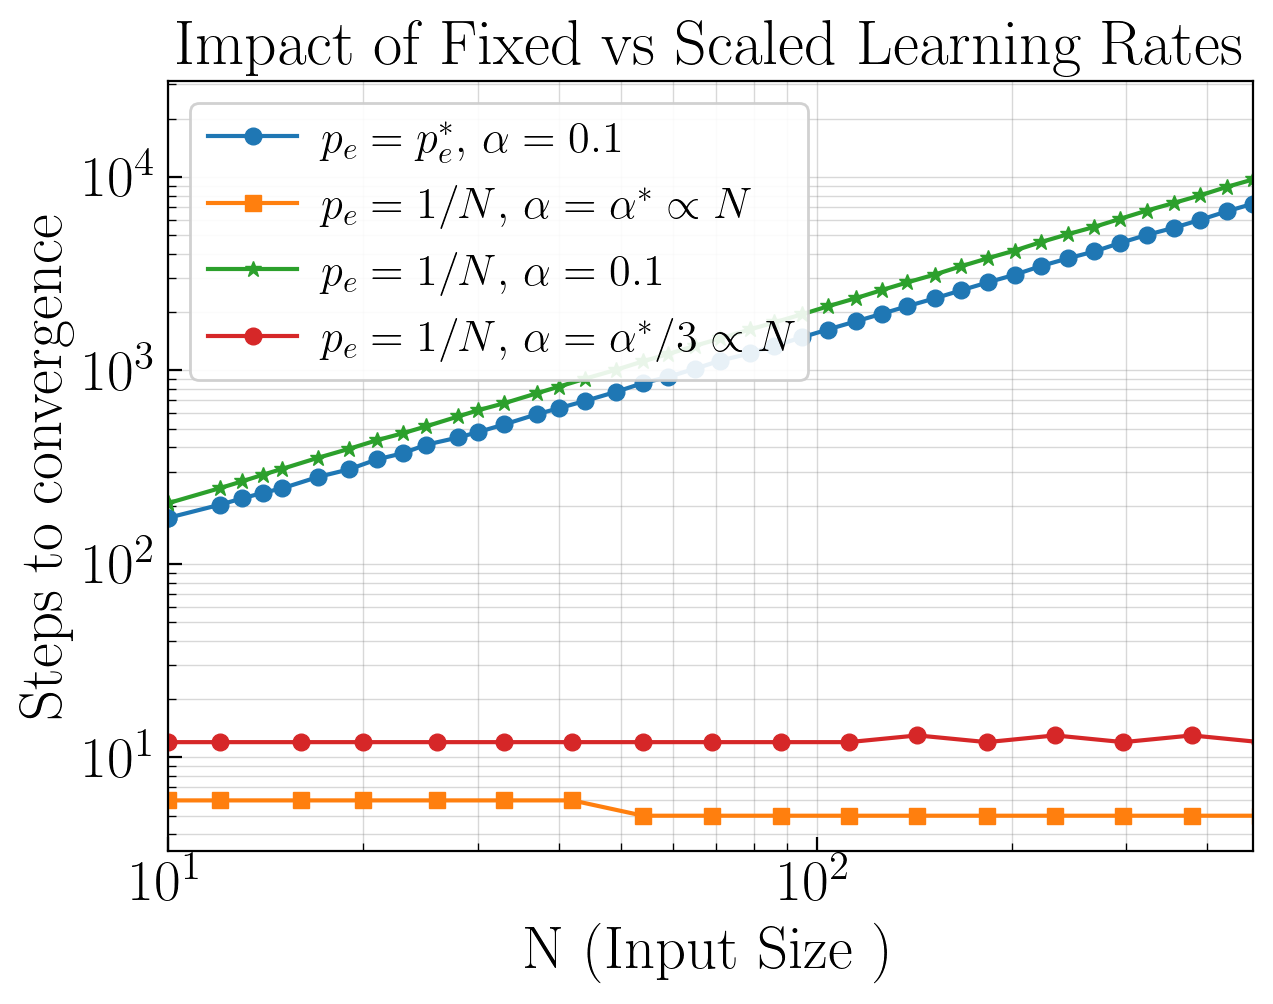

In [4]:
study_b_pattern = '../studies/results/B_p_e_optimal_*/'
study_b_folders = glob.glob(study_b_pattern)

if study_b_folders:
    study_b_dir = max(study_b_folders)
    print(f"Found Study B results: {study_b_dir}")
    
    try:
        # FROM STUDY B
        n_values_b = np.load(study_b_dir + 'n_values.npy')
        optimal_steps_b = np.load(study_b_dir + 'optimal_steps_per_n.npy')
        steps_to_convergence_at_pe_1_over_N = []

        for N in n_values_b:
            p_e_values = np.load(f"{study_b_dir}/N_{N}_p_e_values.npy")

            # Get the closest p_e index to 1/N
            target_p_e = 1 / N
            p_diff = np.abs(p_e_values - target_p_e)
            closest_index = np.argmin(p_diff)

            # Get corresponding p_diff evolution
            p_diff_matrix = np.load(f"{study_b_dir}/N_{N}_p_diff_matrix.npy")
            p_diff_at_pe_1_over_N = p_diff_matrix[closest_index, :]

            # N steps to convergence at p_e = 1/N
            found_step = False
            for step in range(len(p_diff_at_pe_1_over_N)):
                if p_diff_at_pe_1_over_N[step] < 0.01:
                    print(f"N={N}: Steps to convergence at p_e=1/N: {step}")
                    steps_to_convergence_at_pe_1_over_N.append(step)
                    found_step = True
                    break
            if not found_step:
                print(f"N={N}: Did not converge at p_e=1/N within max steps.")
                steps_to_convergence_at_pe_1_over_N.append(10000)

        # FROM STUDY D
        print(results_dir)
        n_values = np.load(results_dir + 'n_values.npy')
        optimal_steps_per_n = np.load(results_dir + 'optimal_steps_per_n.npy')
        steps_to_convergence_at_alpha_over_N = []
        for N in n_values:
            alpha_values = np.load(results_dir + f'N_{N}_alpha_values.npy')
            p_diff_matrix = np.load(results_dir + f'N_{N}_p_diff_matrix.npy')
                                    
            # Get the closest alpha index to alpha = 0.1
            target_alpha = 0.1
            alpha_diff = np.abs(alpha_values - target_alpha)
            closest_alpha_index = np.argmin(alpha_diff)
            print(f"N={N}: Closest alpha to 0.1 is {alpha_values[closest_alpha_index]:.6f} at index {closest_alpha_index}. $\alpha^*=${N/2}")

            # Get corresponding p_diff evolution
            p_diff_at_alpha = p_diff_matrix[closest_alpha_index, :]
            
            # N steps to convergence at alpha 
            found_step = False
            for step in range(len(p_diff_at_alpha)):
                if p_diff_at_alpha[step] < 0.01:
                    print(f"N={N}: Steps to convergence at alpha: {step}")
                    steps_to_convergence_at_alpha_over_N.append(step)
                    found_step = True
                    break
            if not found_step:
                print(f"N={N}: Did not converge at alpha within max steps.")
        
        fig, ax = plt.subplots()
        ax.plot(n_values_b, optimal_steps_b, marker='o', label=r'$p_e=p_e^*$, $\alpha=0.1$')
        ax.plot(n_values, optimal_steps_per_n, marker='s', label=r'$p_e=1/N$, $\alpha=\alpha^* \propto N$')
        ax.plot(n_values_b, steps_to_convergence_at_pe_1_over_N, marker='*', label=r'$p_e=1/N$, $\alpha=0.1$')
        ax.plot(n_values, steps_to_convergence_at_alpha_over_N, marker='o', label=r'$p_e=1/N$, $\alpha=\alpha^*/3 \propto N$')
        
        ax.set_xlabel('N (Input Size )')
        ax.set_ylabel('Steps to convergence')
        ax.set_title(r"Impact of Fixed vs Scaled Learning Rates")
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(n_values_b[0], n_values_b[-9])

        ax.legend()

        plt.show()
    except Exception as e:
        print(f"Error loading Study B results: {e}")
else:
    print("Study B results not found. Run run_study_B.py first.")


N range: 10 to 1000


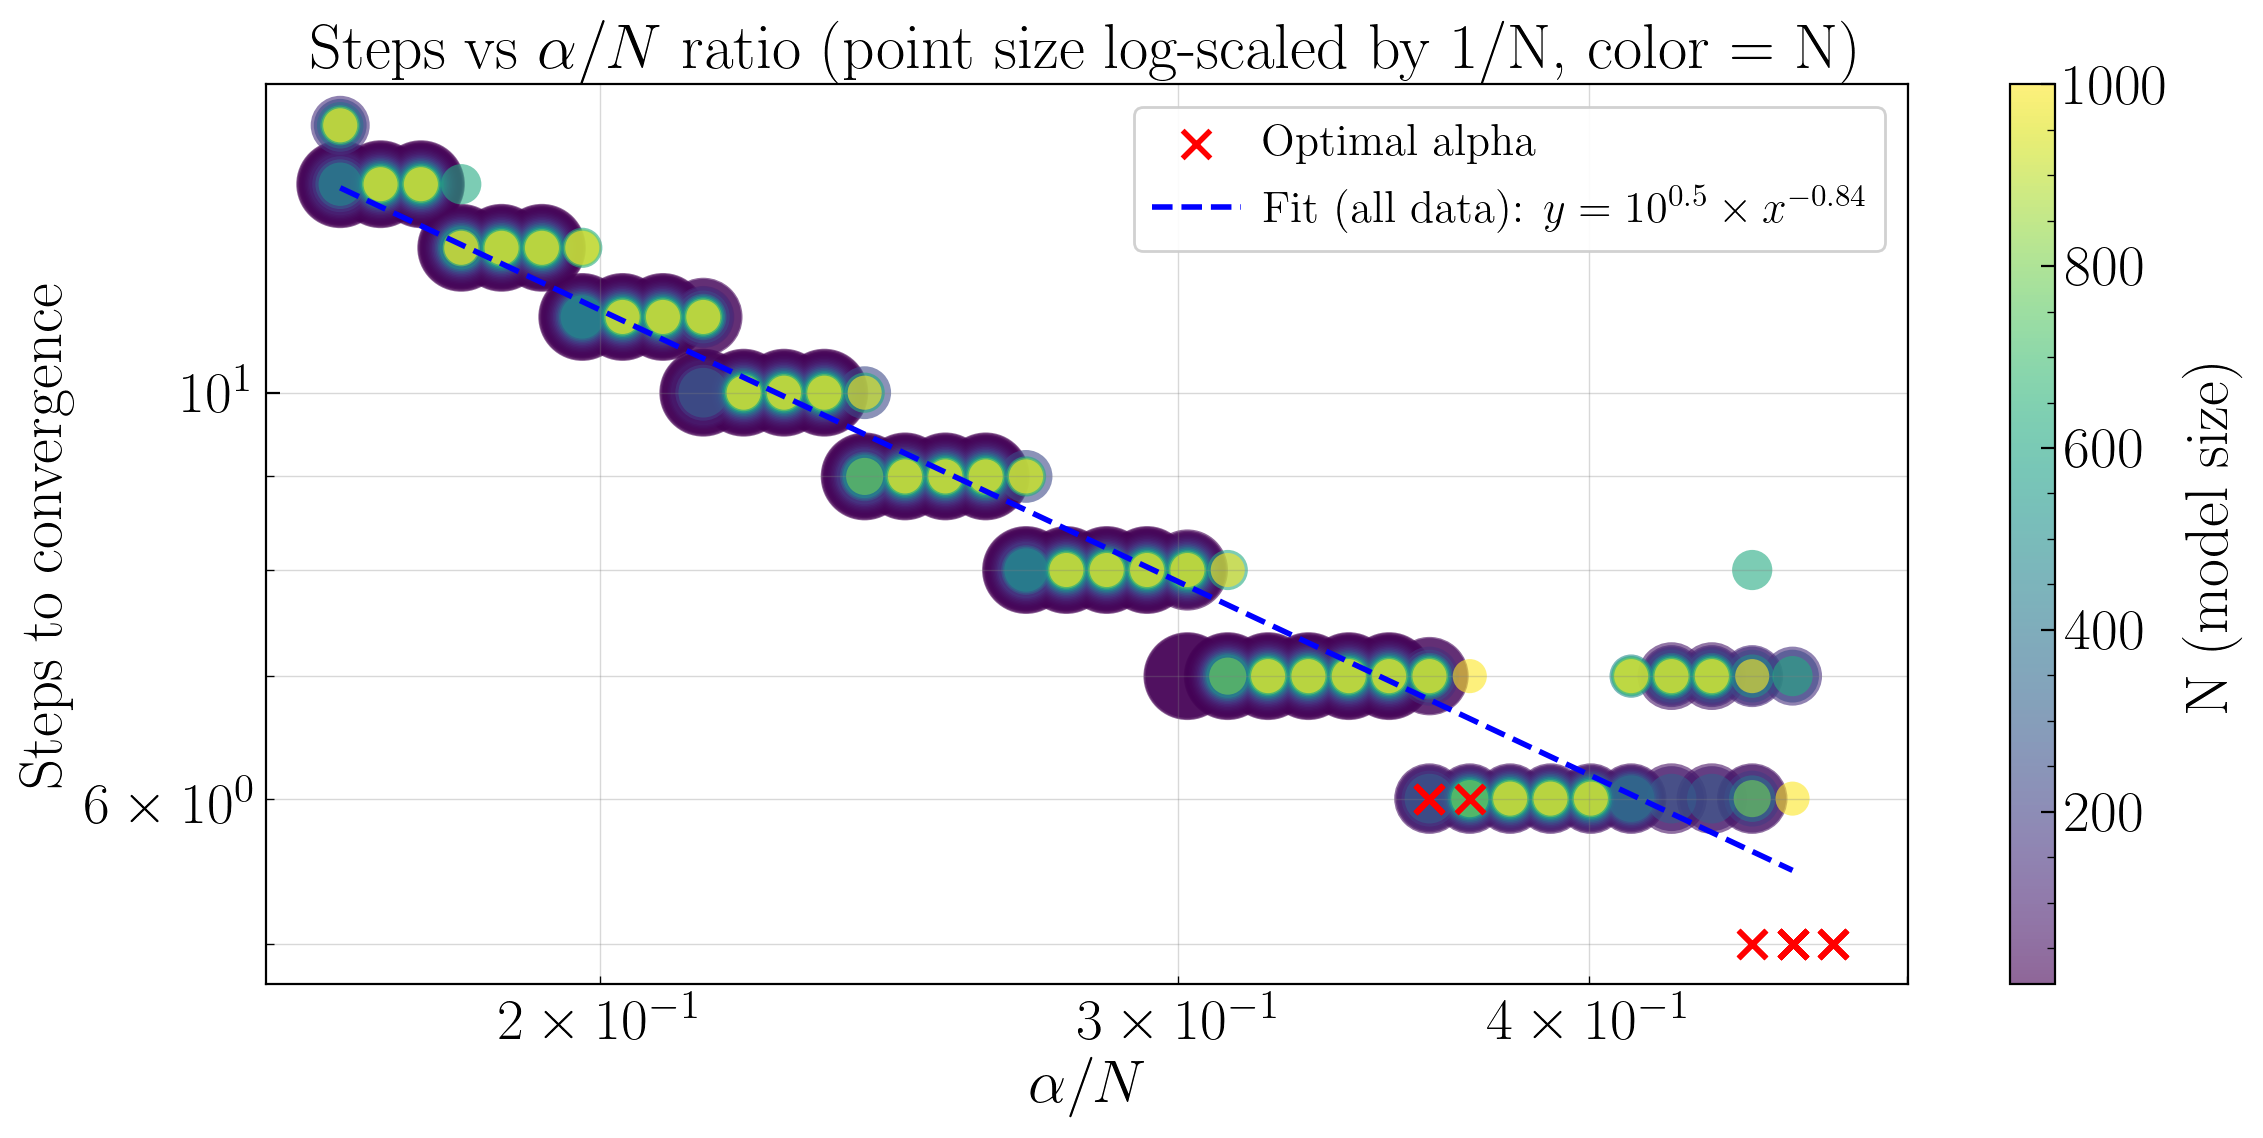

In [5]:
# Same for all alpha values below optimal (not only optimal alpha)
n_values = np.load(results_dir + 'n_values.npy')
optimal_alpha_per_n = np.load(results_dir + 'optimal_alpha_per_n.npy')
optimal_steps_per_n = np.load(results_dir + 'optimal_steps_per_n.npy')

print(f"\nN range: {n_values[0]} to {n_values[-1]}")

fig, ax = plt.subplots(figsize=(12, 6))

# Create a colormap
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# Normalize N values for color mapping
norm = Normalize(vmin=n_values.min(), vmax=n_values.max())
cmap = cm.viridis

# Collect all points for scatter plot with color and size based on N
all_ratios = []
all_steps = []
all_n_values = []

for N, optimal_alpha in zip(n_values, optimal_alpha_per_n):
    alpha_per_n = np.load(results_dir + f'N_{N}_alpha_values.npy')
    steps_per_n = np.load(results_dir + f'N_{N}_steps.npy')
    for alpha, steps in zip(alpha_per_n, steps_per_n):
        if alpha < optimal_alpha:
            print(f"  N={N:4d}: alpha={alpha:.6f}, steps={steps:4.0f}", end='\r')
            alpha_over_n_ratio = alpha / N
            all_ratios.append(alpha_over_n_ratio)
            all_steps.append(steps)
            all_n_values.append(N)

# Convert to arrays
all_ratios = np.array(all_ratios)
all_steps = np.array(all_steps)
all_n_values = np.array(all_n_values)

# Size with logarithmic scale: smaller N = larger points (for background visibility)
sizes = 500 * np.log10(n_values.max() / all_n_values + 1)

# Create scatter plot with colorbar and variable sizes
scatter = ax.scatter(all_ratios, all_steps, c=all_n_values, cmap=cmap, 
                     norm=norm, s=sizes, alpha=0.6, edgecolors='none')

# Add optimal points as red crosses on top
optimal_ratios = optimal_alpha_per_n / n_values
ax.scatter(optimal_ratios, optimal_steps_per_n, c='red', marker='x', s=100, 
           linewidths=2, label='Optimal alpha', zorder=10)

# Fit a line through all data points in log-log space
log_all_ratios = np.log10(all_ratios)
log_all_steps = np.log10(all_steps)
coeffs = np.polyfit(log_all_ratios, log_all_steps, 1)
fit_ratios = np.logspace(np.log10(all_ratios.min()), np.log10(all_ratios.max()), 100)
fit_steps = 10**(coeffs[0] * np.log10(fit_ratios) + coeffs[1])
ax.plot(fit_ratios, fit_steps, 'b--', linewidth=2, 
        label=f'Fit (all data): $y = 10^{{{coeffs[1]:.1f}}} \\times x^{{{coeffs[0]:.2f}}}$', zorder=9)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, label='N (model size)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$\\alpha / N$')
ax.set_ylabel('Steps to convergence')
ax.set_title('Steps vs $\\alpha/N$ ratio (point size log-scaled by 1/N, color = N)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()